In [291]:
import xarray as xr
import fsspec
import zarr
import dask.array as da
import numpy as np
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime, timedelta
from metpy.calc import lat_lon_grid_deltas, vorticity, smooth_gaussian
from metpy.units import units

In [ ]:
allLevelsFile = '../data/sandy2012-windUV_all_levels_from_250_to_850-rechunked.zarr'
subsetLevelsFile = '../data/sandy2012-windUV_250_500_850.zarr'
sandyCoordsFile = "../data/sandy2012-coords.csv"

allLevelsDs = xr.open_zarr(allLevelsFile, consolidated=False)
subsetLevelsDs = xr.open_zarr(subsetLevelsFile, consolidated=False)
sandyCoords = pd.read_csv(sandyCoordsFile)

In [ ]:
sandyCoords["datetime"] = pd.to_datetime(sandyCoords["datetime"])
sandyCoords = sandyCoords.sort_values("datetime").reset_index(drop=True)

sandyCoords["lat"] = sandyCoords["lat"].astype(float)
sandyCoords["lon"] = sandyCoords["lon"].astype(float)
sandyCoords


In [244]:
def get_uv_at_level_time(ds, level, time):
    """
    Select u, v, lats, lons from an xarray Dataset at a given pressure level and time.

    Assumptions:
      - u and v are always shaped (nlat, nlon), e.g. (721, 1440)
      - latitude corresponds to axis 0
      - longitude corresponds to axis 1

    Normalization:
      - If lats are decreasing, flip lats and flip u/v along axis 0.
      - If lons are in [0, 360), convert to [-180, 180) and reorder u/v along axis 1.
    """
    sel = ds.sel(time=time, level=level)

    u = sel["u"].values
    v = sel["v"].values
    lats = sel["latitude"].values
    lons = sel["longitude"].values

    # ---- Latitude: ensure increasing (-90 -> 90) ----
    if len(lats) > 1 and lats[0] > lats[-1]:
        lats = lats[::-1]
        u = u[::-1, :]
        v = v[::-1, :]

    # ---- Longitude: ensure [-180, 180) instead of [0, 360) ----
    # Heuristic: if any lon > 180, treat as 0..360 convention.
    if len(lons) > 0 and np.nanmax(lons) > 180:
        lons_wrapped = ((lons + 180) % 360) - 180   # -> [-180, 180)
        order = np.argsort(lons_wrapped)

        lons = lons_wrapped[order]
        u = u[:, order]
        v = v[:, order]

    return u, v, lats, lons

u, v, lats, lons = get_uv_at_level_time(
    subsetLevelsDs,
    level=850,
    time="2012-10-29T00:00:00",
)

In [ ]:
def interp_storm_latlon(storm_df, time):
    t = pd.to_datetime(time)

    dt = storm_df["datetime"].values

    if t.to_datetime64() < dt[0] or t.to_datetime64() > dt[-1]:
        return None

    exact = storm_df.loc[storm_df["datetime"] == t]
    if len(exact) > 0:
        return float(exact["lat"].iloc[0]), float(exact["lon"].iloc[0])

    i = np.searchsorted(dt, t.to_datetime64(), side="right")
    i0, i1 = i - 1, i

    t0 = storm_df["datetime"].iloc[i0]
    t1 = storm_df["datetime"].iloc[i1]

    frac = (t - t0) / (t1 - t0)

    lat0, lat1 = storm_df["lat"].iloc[i0], storm_df["lat"].iloc[i1]
    lon0, lon1 = storm_df["lon"].iloc[i0], storm_df["lon"].iloc[i1]

    lat = float(lat0 + frac * (lat1 - lat0))
    lon = float(lon0 + frac * (lon1 - lon0))

    return lat, lon

def plot_wind_quiver_single_uv(
    u,
    v,
    lats,
    lons,
    *,
    time=None,                          # only used for storm dot interpolation
    stride: int = 10,
    extent=None,
    max_speed_for_black=None,
    ax=None,
    title: str | None = None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    """
    Core renderer: given u/v + lat/lon arrays for ONE time, plot quiver + coastline +
    optional storm dot at `time` (and +6h dot).
    """
    Lon, Lat = np.meshgrid(lons, lats)

    Lon_s = Lon[::stride, ::stride]
    Lat_s = Lat[::stride, ::stride]
    u_s   = u[::stride, ::stride]
    v_s   = v[::stride, ::stride]

    speed = np.sqrt(u_s**2 + v_s**2)

    if max_speed_for_black is None:
        max_speed_for_black = float(np.nanpercentile(speed, 95)) if np.isfinite(speed).any() else 1.0
        if max_speed_for_black <= 0:
            max_speed_for_black = 1.0

    if ax is None:
        fig = plt.figure(figsize=(6, 4))
        ax = plt.axes(projection=ccrs.PlateCarree())
    else:
        fig = None

    ax.set_facecolor("white")

    if extent is not None:
        lon_min, lon_max, lat_min, lat_max = extent
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

    ax.quiver(
        Lon_s, Lat_s, u_s, v_s, speed,
        transform=ccrs.PlateCarree(),
        cmap="Greys",
        clim=(0.0, max_speed_for_black),
        scale=1500,
        width=0.0012,
        pivot="middle",
    )

    # storm dots (needs time)
    if show_storm_dot and storm_df is not None and time is not None:
        pt = interp_storm_latlon(storm_df, time)
        if pt is not None:
            lat_pt, lon_pt = pt
            ax.scatter(
                [lon_pt], [lat_pt],
                transform=ccrs.PlateCarree(),
                s=storm_dot_size,
                c="red",
                edgecolors="none",
                zorder=10,
            )

            t_next = pd.to_datetime(time) + pd.Timedelta(hours=6)
            pt2 = interp_storm_latlon(storm_df, t_next)
            if pt2 is not None:
                lat2, lon2 = pt2
                ax.scatter(
                    [lon2], [lat2],
                    transform=ccrs.PlateCarree(),
                    s=storm_dot_size,
                    c="#ff9999",
                    edgecolors="none",
                    zorder=10,
                )
                ax.plot(
                    [lon_pt, lon2],
                    [lat_pt, lat2],
                    transform=ccrs.PlateCarree(),
                    color="red",
                    linewidth=1.5,
                    zorder=9,
                )

    if title is not None:
        ax.set_title(title)

    return fig, ax


def plot_wind_quiver_single_from_ds(
    ds,
    pressure_hpa: int,
    time,
    *,
    stride: int = 10,
    extent=None,
    max_speed_for_black=None,
    ax=None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    """
    Convenience wrapper: select u/v from ds at (time, pressure_hpa), then call core UV plotter.
    """
    sel = ds.sel(level=pressure_hpa).sel(time=time)

    u = sel["u"].values
    v = sel["v"].values
    lats = sel["latitude"].values
    lons = sel["longitude"].values

    return plot_wind_quiver_single_uv(
        u,
        v,
        lats,
        lons,
        time=time,
        stride=stride,
        extent=extent,
        max_speed_for_black=max_speed_for_black,
        ax=ax,
        title=f"{pressure_hpa} hPa",
        storm_df=storm_df,
        show_storm_dot=show_storm_dot,
        storm_dot_size=storm_dot_size,
    )


def plot_wind_quiver_levels_side_by_side(
    ds,
    pressure_levels,
    time,
    *,
    stride: int = 10,
    extent=None,
    # max_speed_for_black=None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    n = len(pressure_levels)

    fig = plt.figure(figsize=(5 * n, 5))
    axes = []
    
    QUIVER_MAX_SPEEDS = {
        850: 35,   # m/s — low-level inflow & storm-scale circulation
        500: 45,   # m/s — mid-level steering flow
        250: 70,   # m/s — upper-level outflow & jet stream
    }


    for i, lvl in enumerate(pressure_levels, start=1):
        ax = fig.add_subplot(1, n, i, projection=ccrs.PlateCarree())
        axes.append(ax)
        max_speed = None
        max_speed = QUIVER_MAX_SPEEDS.get(lvl, None)

        plot_wind_quiver_single_from_ds(
            ds,
            lvl,
            time,
            stride=stride,
            extent=extent,
            max_speed_for_black=max_speed,
            ax=ax,
            storm_df=storm_df,
            show_storm_dot=show_storm_dot,
            storm_dot_size=storm_dot_size,
        )

    fig.suptitle(f"Wind Quivers — {time}", y=0.98)
    fig.tight_layout(w_pad=0.2)

    return fig, axes


In [ ]:
# pick the levels you care about
levels = [250, 500, 850]

# select time + levels
sel = subsetLevelsDs.sel(time="2012-10-29T00:00:00", level=levels)

# average u/v across level -> (latitude, longitude)
u_avg = sel["u"].mean(dim="level").values
v_avg = sel["v"].mean(dim="level").values

# coords (1D arrays)
lats = sel["latitude"].values
lons = sel["longitude"].values

fig, ax = plot_wind_quiver_single_uv(
    u_avg,
    v_avg,
    lats,
    lons,
    time="2012-10-29T00:00:00",
    stride=7,
    extent=(-100, 0, -10, 55),
    storm_df=sandyCoords,
    title='Averaged Flow'
)

plt.show()


In [ ]:
start = datetime.fromisoformat("2012-10-22T00:00")
end   = datetime.fromisoformat("2012-10-31T12:00")

t = start
while t <= end:
    fig, axes = plot_wind_quiver_levels_side_by_side(
        subsetLevelsDs,
        [250, 500, 850],
        # "2012-10-29T00:00:00",       
        t.strftime("%Y-%m-%dT%H:%M:%S"),
        stride=7,
        extent=(-130, 0, -10, 85),
        storm_df=sandyCoords,       
    )
    plt.show()
    
    t += np.timedelta64(6, "h")

In [ ]:
levels = 500
time = "2012-10-29T00:00:00"

sel = subsetLevelsDs.sel(time=time, level=levels)

u500 = sel["u"].values
v500 = sel["v"].values
lats = sel["latitude"].values
lons = sel["longitude"].values

# Ensure U/V are (lat, lon)
U, V = u500, v500
if U.shape != (len(lats), len(lons)):
    U, V = U.T, V.T

lats2 = lats.copy()

# Flip latitude to be increasing
if lats2[0] > lats2[-1]:
    lats2 = lats2[::-1]
    U = U[::-1, :]
    V = V[::-1, :]

# Convert 0–360 -> -180–180 and sort longitude
lons2 = ((lons + 180) % 360) - 180
order = np.argsort(lons2)
lons2 = lons2[order]
U = U[:, order]
V = V[:, order]

# Speed aligned with sorted/flipped U/V (use this for imshow!)
speed2 = np.hypot(U, V)

# Downsample for plotting
s = 10
lats_s = lats2[::s]
lons_s = lons2[::s]
U_s = U[::s, ::s]
V_s = V[::s, ::s]

# Threshold mask (used for quiver sparsification + streamline start points)
spd_s = np.hypot(U_s, V_s)
thr = np.nanpercentile(spd_s, 92)

# Streamline start points: seed only where spd is high (but integrate on full field)
iy, ix = np.where(spd_s >= thr)
# step = 6  # bigger -> fewer streamlines
# iy = iy[::step]
# ix = ix[::step]
# start_points = np.column_stack([lons_s[ix], lats_s[iy]])

# min spacing in downsampled grid cells (tune this!)
min_dy = 6    # ~6* s grid steps in latitude
min_dx = 10   # ~10* s grid steps in longitude

# Sort seeds so we pick "strongest" first (better than random)
# (so we keep the core of the jet first)
seed_strength = spd_s[iy, ix]
order2 = np.argsort(seed_strength)[::-1]
iy = iy[order2]
ix = ix[order2]

kept = []
taken = np.zeros_like(spd_s, dtype=bool)

for y, x in zip(iy, ix):
    if taken[y, x]:
        continue
    kept.append((y, x))
    y0 = max(0, y - min_dy); y1 = min(taken.shape[0], y + min_dy + 1)
    x0 = max(0, x - min_dx); x1 = min(taken.shape[1], x + min_dx + 1)
    taken[y0:y1, x0:x1] = True

kept = np.array(kept)
iy_k = kept[:, 0]
ix_k = kept[:, 1]

start_points = np.column_stack([lons_s[ix_k], lats_s[iy_k]])

In [ ]:
# 2) Quiver plot (uses NaN-masked field)
fig2, ax2 = plt.subplots(
    figsize=(12, 6),
    subplot_kw=dict(projection=ccrs.PlateCarree())
)

plot_wind_quiver_single_uv(
    U_s,
    V_s,
    lats_s,
    lons_s,
    time=time,
    stride=1,
    extent=(-180, 180, -90, 90),
    ax=ax2,
    storm_df=sandyCoords,
)
plt.show()


# 1) Streamlines plot (integrate on full field, seed only in fast corridors)
fig, ax = plt.subplots(figsize=(12, 6))

ax.imshow(
    speed2,
    origin="lower",
    extent=(lons2.min(), lons2.max(), lats2.min(), lats2.max()),
    aspect="auto",
    alpha=0.35,
)

ax.streamplot(
    lons_s, lats_s, U_s, V_s,
    start_points=start_points,
    integration_direction="both",
    maxlength=20.0,           # makes them long + traceable
    minlength=0.5,
    broken_streamlines=False,
    linewidth=1.2,
    arrowsize=1.2,
)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_title(f"500 hPa Streamlines — {time}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [ ]:
def haversine_km(lat, lon, lat0, lon0):
    R = 6371.0
    lat = np.deg2rad(lat); lon = np.deg2rad(lon)
    lat0 = np.deg2rad(lat0); lon0 = np.deg2rad(lon0)
    dlat = lat - lat0
    dlon = lon - lon0
    a = np.sin(dlat/2)**2 + np.cos(lat)*np.cos(lat0)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def ring_mean_uv(U, V, lats, lons, lat0, lon0, r_in_km=300, r_out_km=600):
    LAT, LON = np.meshgrid(lats, lons, indexing="ij")
    dist = haversine_km(LAT, LON, lat0, lon0)
    mask = (dist >= r_in_km) & (dist <= r_out_km)

    # area-ish weights for lat/lon grid
    w = np.cos(np.deg2rad(LAT))
    w = np.where(mask, w, 0.0)

    # ignore NaNs in U/V too
    good = np.isfinite(U) & np.isfinite(V) & (w > 0)
    w2 = np.where(good, w, 0.0)

    u_bar = np.sum(U * w2) / np.sum(w2)
    v_bar = np.sum(V * w2) / np.sum(w2)
    return u_bar, v_bar, dist, mask

def advect_latlon(lat0, lon0, u_ms, v_ms, dt_hours):
    # u eastward (m/s), v northward (m/s)
    R = 6371000.0
    dt = dt_hours * 3600.0

    lat0r = np.deg2rad(lat0)
    dlat = (v_ms * dt) / R
    dlon = (u_ms * dt) / (R * np.cos(lat0r))

    lat1 = lat0 + np.rad2deg(dlat)
    lon1 = lon0 + np.rad2deg(dlon)
    return lat1, lon1

def plot_quiver_with_steering_ring(
    U,
    V,
    lats,
    lons,
    *,
    time=None,
    lat0=None,
    lon0=None,
    storm_df=None,
    storm_time_col="datetime",
    storm_lat_col="lat",
    storm_lon_col="lon",
    r_in_km=300,
    r_out_km=600,
    arrow_hours=6,
    extent=(-120, 0, 0, 90),
    stride=1,
    ax=None,
    figsize=(12, 6),
    quiver_plotter=None,  # optional: your plot_wind_quiver_single_uv
):
    """
    Plots a quiver field and overlays:
      - distance-ring contours (r_in_km, r_out_km)
      - a steering endpoint (advection of ring-mean wind for arrow_hours)

    Provide storm center either:
      (lat0, lon0) directly, OR
      storm_df + time (to look up center).

    If you pass quiver_plotter=plot_wind_quiver_single_uv, it will be used.
    Otherwise, a basic ax.quiver will be used.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(projection=ccrs.PlateCarree()))
    else:
        fig = ax.figure

    # Determine storm center
    if (lat0 is None) or (lon0 is None):
        if (storm_df is None) or (time is None):
            raise ValueError("Provide (lat0, lon0) or (storm_df and time).")
        row = storm_df.loc[storm_df[storm_time_col] == time].iloc[0]
        lat0 = float(row[storm_lat_col])
        lon0 = float(row[storm_lon_col])

    # Plot quiver field
    if quiver_plotter is not None:
        # uses your existing function, so it can keep coastlines, titles, etc.
        quiver_plotter(
            U, V, lats, lons,
            time=time,
            stride=stride,
            extent=extent,
            ax=ax,
            storm_df=storm_df,
        )
    else:
        # basic fallback
        LAT, LON = np.meshgrid(lats, lons, indexing="ij")
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.quiver(
            LON[::stride, ::stride],
            LAT[::stride, ::stride],
            U[::stride, ::stride],
            V[::stride, ::stride],
            transform=ccrs.PlateCarree(),
        )
        ax.scatter([lon0], [lat0], transform=ccrs.PlateCarree(), s=30)

    # Ring-mean steering
    u_bar, v_bar, dist_km, mask = ring_mean_uv(U, V, lats, lons, lat0, lon0, r_in_km, r_out_km)

    # Ring contours
    LAT, LON = np.meshgrid(lats, lons, indexing="ij")
    ax.contour(
        LON, LAT, dist_km, levels=[r_in_km],
        transform=ccrs.PlateCarree(), linewidths=2
    )
    ax.contour(
        LON, LAT, dist_km, levels=[r_out_km],
        transform=ccrs.PlateCarree(), linewidths=2
    )

    # Endpoint marker (6h advection by default)
    if np.isfinite(u_bar) and np.isfinite(v_bar):
        lat1, lon1 = advect_latlon(lat0, lon0, u_bar, v_bar, arrow_hours)
        ax.scatter([lon1], [lat1], transform=ccrs.PlateCarree(), s=40)

    # Title (don’t clobber a custom title if your quiver_plotter already set one)
    ax.set_title(
        f"Ring-mean steering: u={u_bar:.1f} m/s, v={v_bar:.1f} m/s  "
        f"({r_in_km}-{r_out_km} km), endpoint={arrow_hours}h"
    )

    return fig, ax, dict(
        lat0=lat0, lon0=lon0,
        u_bar=u_bar, v_bar=v_bar,
        r_in_km=r_in_km, r_out_km=r_out_km,
        arrow_hours=arrow_hours,
    )

# ---- your existing plot ----
# fig2, ax2 = plt.subplots(figsize=(12, 6), subplot_kw=dict(projection=ccrs.PlateCarree()))

# plot_wind_quiver_single_uv(
#     U_s, V_s, lats_s, lons_s,
#     time=time,
#     stride=1,
#     extent=(-120, 0, 0, 90),
#     ax=ax2,
#     storm_df=sandyCoords,
# )

# # 1) get storm center at this time (adjust to however your sandyCoords is structured)
# row = sandyCoords.loc[sandyCoords["datetime"] == time].iloc[0]
# lat0 = float(row["lat"])
# lon0 = float(row["lon"])

# # 2) ring + mean flow
# r_in_km, r_out_km = 300, 600
# u_bar, v_bar, dist_km, mask = ring_mean_uv(U_s, V_s, lats_s, lons_s, lat0, lon0, r_in_km, r_out_km)

# # 3) draw the ring as contours of the distance field
# # (this shows the “circle” even on a lat/lon grid)
# LAT, LON = np.meshgrid(lats_s, lons_s, indexing="ij")
# ax2.contour(LON, LAT, dist_km, levels=[r_in_km], transform=ccrs.PlateCarree(),
#             linewidths=2)
# ax2.contour(LON, LAT, dist_km, levels=[r_out_km], transform=ccrs.PlateCarree(),
#             linewidths=2)

# arrow_hours = 6
# lat1, lon1 = advect_latlon(lat0, lon0, u_bar, v_bar, arrow_hours)
# ax2.scatter([lon1], [lat1], transform=ccrs.PlateCarree(), s=40)

# ax2.set_title(f"Ring-mean steering: u={u_bar:.1f} m/s, v={v_bar:.1f} m/s  ({r_in_km}-{r_out_km} km)")
# plt.show()
u, v, lats, lons = get_uv_at_level_time(
    subsetLevelsDs,
    level=850,
    time="2012-10-29T00:00:00",
)

fig, ax, info = plot_quiver_with_steering_ring(
    u, v, lats, lons,
    time=time,
    storm_df=sandyCoords,
    extent=(-120, 0, 0, 90),
    stride=10,
    r_in_km=300,
    r_out_km=600,
    arrow_hours=6,
    quiver_plotter=plot_wind_quiver_single_uv,
)
plt.show()


In [ ]:
levels = [250, 500, 850]
r_in_km, r_out_km = 500, 1000

start_time = datetime.fromisoformat("2012-10-25T00:00:00")
end_time   = datetime.fromisoformat("2012-10-30T00:00:00")

time = start_time
while time <= end_time:
    time_str = time.isoformat()

    fig, axes = plt.subplots(
        1, 3,
        figsize=(18, 6),
        constrained_layout=True,
        subplot_kw={"projection": ccrs.PlateCarree()},
    )

    for ax, level in zip(axes, levels):
        u, v, lats, lons = get_uv_at_level_time(
            subsetLevelsDs,
            level=level,
            time=time_str,
        )

        plot_quiver_with_steering_ring(
            u, v, lats, lons,
            ax=ax,
            time=time_str,
            storm_df=sandyCoords,
            extent=(-160, 0, 0, 90),
            stride=10,
            r_in_km=r_in_km,
            r_out_km=r_out_km,
            arrow_hours=6,
            quiver_plotter=plot_wind_quiver_single_uv,
        )

        ax.set_title(f"{level} hPa")

    fig.suptitle(f"Sandy steering flow — {time_str}", fontsize=16)
    plt.show()

    time += timedelta(hours=6)

250 hPa storm influence radius ≈ 238 km; steering ring = [238, 638] km
300 hPa storm influence radius ≈ 288 km; steering ring = [288, 688] km
350 hPa storm influence radius ≈ 312 km; steering ring = [312, 712] km
400 hPa storm influence radius ≈ 312 km; steering ring = [312, 712] km
450 hPa storm influence radius ≈ 338 km; steering ring = [338, 738] km
500 hPa storm influence radius ≈ 888 km; steering ring = [888, 1288] km
550 hPa storm influence radius ≈ 962 km; steering ring = [962, 1362] km
600 hPa storm influence radius ≈ 962 km; steering ring = [962, 1362] km
650 hPa storm influence radius ≈ 938 km; steering ring = [938, 1338] km
700 hPa storm influence radius ≈ 938 km; steering ring = [938, 1338] km
750 hPa storm influence radius ≈ 988 km; steering ring = [988, 1388] km
800 hPa storm influence radius ≈ 988 km; steering ring = [988, 1388] km
850 hPa storm influence radius ≈ 988 km; steering ring = [988, 1388] km


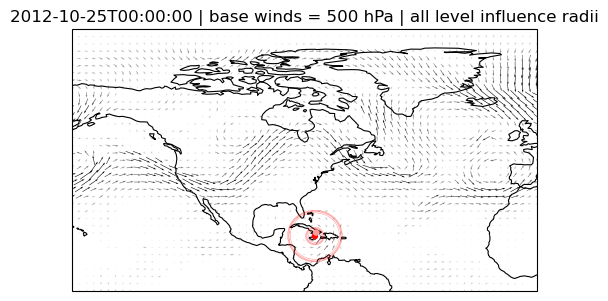

In [288]:
def compute_storm_influence_radius_tangential(
    U, V, lats, lons,
    center_lat, center_lon,
    threshold_ms=10.0,
    dr_km=25.0,
    r_min_km=50.0,
    r_max_km=1500.0,
    require_consecutive=2,
):
    """
    Storm influence radius (km) at a level/time:
    - Compute tangential wind about the storm center at each grid cell (CCW-positive).
    - Average tangential wind in concentric rings.
    - Find the first radius moving outward where the ring-mean tangential wind drops below
      threshold (optionally requiring it to stay below for N consecutive rings).

    Returns:
      r_influence_km, ring_centers_km, ring_mean_tangential_ms
    """
    Lon, Lat = np.meshgrid(lons, lats)

    # Local tangent-plane distances from center (km)
    km_per_deg_lat = 111.32
    dx = (Lon - center_lon) * km_per_deg_lat * np.cos(np.deg2rad(center_lat))  # east-positive
    dy = (Lat - center_lat) * km_per_deg_lat                                  # north-positive

    r = np.sqrt(dx * dx + dy * dy)
    r = np.where(r == 0, np.nan, r)

    # Tangential unit vector (CCW): (-dy/r, dx/r)
    tx = -dy / r
    ty =  dx / r

    # Signed tangential wind (CCW-positive), m/s
    Vtan = U * tx + V * ty

    # Ring bins
    edges = np.arange(0.0, r_max_km + dr_km, dr_km)
    centers = 0.5 * (edges[:-1] + edges[1:])
    means = np.full_like(centers, np.nan, dtype=float)

    for i in range(len(centers)):
        r0, r1 = edges[i], edges[i + 1]
        mask = (r >= r0) & (r < r1)
        if np.any(mask):
            means[i] = np.nanmean(Vtan[mask])

    # Only search beyond a minimum radius
    start_idx = np.searchsorted(centers, r_min_km)

    # Find first ring where mean < threshold for N consecutive rings
    r_influence = None
    below = means < threshold_ms
    for i in range(start_idx, len(centers) - require_consecutive + 1):
        if np.all(below[i : i + require_consecutive]):
            r_influence = centers[i]
            break

    # Fallback if never drops below threshold in range
    if r_influence is None:
        r_influence = centers[-1]

    return float(r_influence), centers, means


# -------------------------
# Example usage for 500 hPa
# -------------------------
time_str = "2012-10-25T00:00:00"

# 1) Storm center at this time (same for all levels)
storm_lat, storm_lon = interp_storm_latlon(sandyCoords, time_str)

# 2) Loop over levels, compute and STORE the influence radius per level
r_in_by_level = {}  # {level_hpa: storm_influence_km}

for level in allLevelsDs.level.values:
    u, v, lats, lons = get_uv_at_level_time(
        allLevelsDs,
        level=float(level),
        time=time_str,
    )

    storm_influence_km, ring_r_km, ring_mean_vtan = compute_storm_influence_radius_tangential(
        u, v, lats, lons,
        center_lat=storm_lat,
        center_lon=storm_lon,
        threshold_ms=10.0,
        dr_km=25.0,
        r_min_km=50.0,
        r_max_km=1500.0,
        require_consecutive=2,
    )

    r_in_by_level[float(level)] = float(storm_influence_km)

    r_out_km = float(storm_influence_km) + 400.0
    print(
        f"{float(level):g} hPa storm influence radius ≈ {storm_influence_km:.0f} km; "
        f"steering ring = [{storm_influence_km:.0f}, {r_out_km:.0f}] km"
    )

# 3) Choose ONE background field to plot (e.g., 500 hPa) and create a single ax
base_level = 500.0 if 500.0 in r_in_by_level else float(list(r_in_by_level.keys())[0])

u0, v0, lats0, lons0 = get_uv_at_level_time(allLevelsDs, level=base_level, time=time_str)

fig, ax = plot_wind_quiver_single_uv(
    u0, v0, lats0, lons0,
    time=time_str,
    stride=10,
    extent=(-160, 0, 0, 90),
    ax=None,
    storm_df=sandyCoords,
    title=f"{time_str} | base winds = {base_level:g} hPa | all level influence radii",
)

# 4) Build a distance field (km) from storm center on the plotting grid
Lon, Lat = np.meshgrid(lons0, lats0)  # (lat, lon)
dist_km = haversine_km(Lat, Lon, storm_lat, storm_lon)

# 5) Overlay ALL stored influence radii as concentric circles
#    (sorted so it visually looks like “bigger and bigger circles”)
levels_sorted = sorted(r_in_by_level.keys())
radii_sorted = [r_in_by_level[lev] for lev in levels_sorted]

# Optional: drop NaNs / non-positive radii
radii_sorted = [r for r in radii_sorted if np.isfinite(r) and r > 0]

ax.contour(
    Lon, Lat, dist_km,
    levels=sorted(set(radii_sorted)),
    transform=ccrs.PlateCarree(),
    linewidths=0.2,
    colors="red",
    alpha=0.75,
)

# Optional: label each ring with its level (can clutter; comment out if too busy)
# for lev in levels_sorted:
#     r = r_in_by_level[lev]
#     if not (np.isfinite(r) and r > 0):
#         continue
#     # place label due east of center (roughly) on the circle
#     lat_lab = storm_lat
#     lon_lab = storm_lon + (r / (111.0 * np.cos(np.deg2rad(storm_lat))))  # approx deg lon per km
#     ax.text(lon_lab, lat_lab, f"{lev:g}", transform=ccrs.PlateCarree(), fontsize=8, color="red")

plt.show()



/home/dmmsp/anaconda3/envs/Hurricane-Track-Explainer/lib/python3.13/site-packages/pint/facets/plain/quantity.py:1031: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


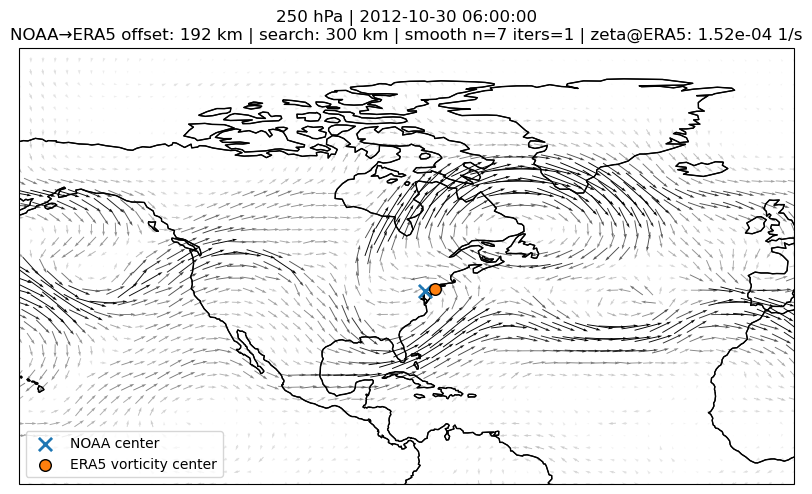

/home/dmmsp/anaconda3/envs/Hurricane-Track-Explainer/lib/python3.13/site-packages/pint/facets/plain/quantity.py:1031: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


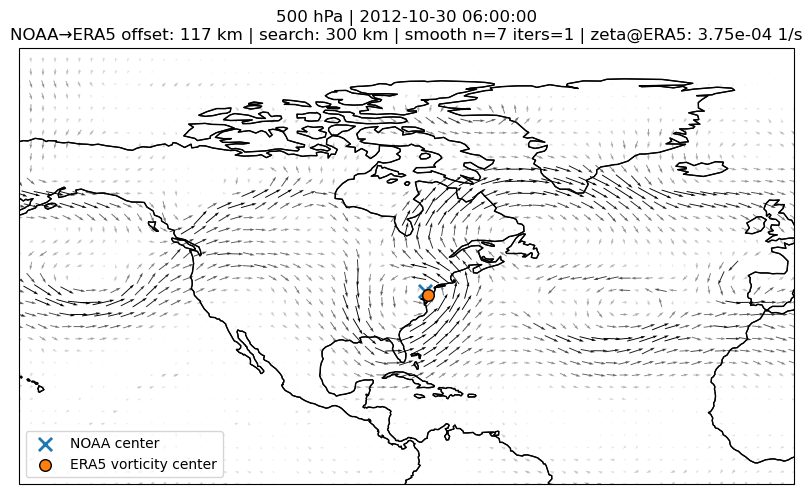

/home/dmmsp/anaconda3/envs/Hurricane-Track-Explainer/lib/python3.13/site-packages/pint/facets/plain/quantity.py:1031: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


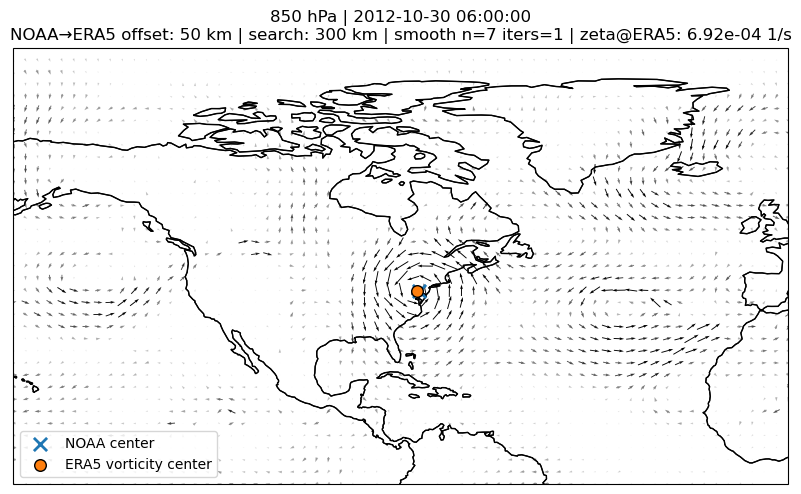

In [298]:
def _approx_distance_km(lat, lon, lat0, lon0):
    km_per_deg = 111.32
    dx = (lon - lon0) * km_per_deg * np.cos(np.deg2rad(lat0))
    dy = (lat - lat0) * km_per_deg
    return np.sqrt(dx * dx + dy * dy)


def _sigma_to_n(sigma):
    """Convert a sigma (gridpoints) into MetPy's required odd window size n."""
    if sigma is None or sigma <= 0:
        return None
    n = int(np.ceil(6.0 * float(sigma) + 1.0))
    n = max(n, 3)
    if n % 2 == 0:
        n += 1
    return n


def find_era5_center_from_uv(
    u, v, lats, lons,
    ref_lat, ref_lon,
    search_km=300.0,
    smooth_sigma=1.0,
    smooth_iters=1,
):
    """
    Returns: (era_lat, era_lon, offset_km, zeta_at_center [1/s])
    """
    U = np.asarray(u)
    V = np.asarray(v)
    lats = np.asarray(lats)
    lons = np.asarray(lons)

    Lon2d, Lat2d = np.meshgrid(lons, lats)

    dx, dy = lat_lon_grid_deltas(Lon2d, Lat2d)  # meters

    zeta = vorticity(U * units("m/s"), V * units("m/s"), dx=dx, dy=dy)  # 1/s

    n = _sigma_to_n(smooth_sigma)
    if n is not None and int(smooth_iters) > 0:
        for _ in range(int(smooth_iters)):
            zeta = smooth_gaussian(zeta, n=n)

    z = np.asarray(zeta.magnitude)

    dist_km = _approx_distance_km(Lat2d, Lon2d, ref_lat, ref_lon)

    # Prefer cyclonic (NH positive) within radius
    cand = (dist_km <= search_km) & np.isfinite(z) & (z > 0)

    if np.any(cand):
        score = np.where(cand, z, np.nan)
        idx = np.nanargmax(score)
        i, j = np.unravel_index(idx, score.shape)
    else:
        # Fallback: max |zeta| within radius
        cand2 = (dist_km <= search_km) & np.isfinite(z)
        if not np.any(cand2):
            raise ValueError("No valid vorticity points found in search window.")
        score = np.where(cand2, np.abs(z), np.nan)
        idx = np.nanargmax(score)
        i, j = np.unravel_index(idx, score.shape)

    era_lat = float(lats[i])
    era_lon = float(lons[j])
    offset_km = float(_approx_distance_km(era_lat, era_lon, ref_lat, ref_lon))
    zeta_val = float(z[i, j])

    return era_lat, era_lon, offset_km, zeta_val


def plot_quiver_with_noaa_and_era5_centers(
    subsetLevelsDs,
    sandyCoords,
    time_str,
    level=500,
    extent=(-160, 0, 0, 90),
    stride=10,
    search_km=300.0,
    smooth_sigma=1.0,
    smooth_iters=1,
):
    u, v, lats, lons = get_uv_at_level_time(subsetLevelsDs, level=level, time=time_str)
    ref_lat, ref_lon = interp_storm_latlon(sandyCoords, time_str)

    era_lat, era_lon, offset_km, zeta_val = find_era5_center_from_uv(
        u, v, lats, lons,
        ref_lat=ref_lat, ref_lon=ref_lon,
        search_km=search_km,
        smooth_sigma=smooth_sigma,
        smooth_iters=smooth_iters,
    )

    fig = plt.figure(figsize=(10, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=1)

    # Always use your quiver plotter
    plot_wind_quiver_single_uv(
        u, v, lats, lons,
        ax=ax,
        time=time_str,
        extent=extent,
        stride=stride,
    )

    ax.scatter(
        [ref_lon], [ref_lat],
        s=90, marker="x", linewidths=2,
        transform=ccrs.PlateCarree(),
        label="NOAA center",
        zorder=10,
    )
    ax.scatter(
        [era_lon], [era_lat],
        s=70, marker="o", edgecolors="k",
        transform=ccrs.PlateCarree(),
        label="ERA5 vorticity center",
        zorder=10,
    )
    ax.plot(
        [ref_lon, era_lon], [ref_lat, era_lat],
        transform=ccrs.PlateCarree(),
        linewidth=1.5,
        zorder=9,
    )

    n = _sigma_to_n(smooth_sigma)
    ax.set_title(
        f"{level} hPa | {time_str}\n"
        f"NOAA→ERA5 offset: {offset_km:.0f} km | search: {search_km:.0f} km | "
        f"smooth n={n} iters={int(smooth_iters)} | zeta@ERA5: {zeta_val:.2e} 1/s"
    )
    ax.legend(loc="lower left")
    plt.show()

    return {
        "noaa_center": (float(ref_lat), float(ref_lon)),
        "era5_center": (float(era_lat), float(era_lon)),
        "offset_km": float(offset_km),
        "zeta_at_era5_center_1_per_s": float(zeta_val),
        "smooth_n": n,
        "smooth_iters": int(smooth_iters),
    }

out = plot_quiver_with_noaa_and_era5_centers(
    subsetLevelsDs=subsetLevelsDs,
    sandyCoords=sandyCoords,
    time_str=time,
    level=250,
    extent=(-160, 0, 0, 90),
    stride=10,
    search_km=300.0,
    smooth_sigma=1.0,
    smooth_iters=1,
)

out = plot_quiver_with_noaa_and_era5_centers(
    subsetLevelsDs=subsetLevelsDs,
    sandyCoords=sandyCoords,
    time_str=time,
    level=500,
    extent=(-160, 0, 0, 90),
    stride=10,
    search_km=300.0,
    smooth_sigma=1.0,
    smooth_iters=1,
)

out = plot_quiver_with_noaa_and_era5_centers(
    subsetLevelsDs=subsetLevelsDs,
    sandyCoords=sandyCoords,
    time_str=time,
    level=850,
    extent=(-160, 0, 0, 90),
    stride=10,
    search_km=300.0,
    smooth_sigma=1.0,
    smooth_iters=1,
)